# Vancouver Airbnb Price Prediction Analysis

## Project Overview
This project uses regression models to predict Airbnb listing prices in Vancouver based on listing, host, review, and availability features. In addition to building predictive models, the analysis aims to identify which factors are most strongly associated with price.

## Project Goal
The main goal is to predict listing price using meaningful features from the dataset and compare multiple regression approaches.

The project will:
- explore and clean the dataset
- create useful engineered features
- compare several regression models
- identify important price-related factors
- summarize practical insights

## Dataset
The dataset used in this project comes from the **Inside Airbnb** platform.

- **Source:** [Inside Airbnb](https://insideairbnb.com/get-the-data/)
- **City:** Vancouver
- **Dataset date:** 17 November 2025
- **Date retrieved:** 22 January 2026

## Models Compared
The following models will be compared in this project:
- Simple Linear Regression
- Multiple Linear Regression
- Ridge Regression
- Lasso Regression
- XGBoost Regressor
- Neural Network Regressor

## Evaluation Metrics
Each model will be evaluated using:
- RMSE
- MAE
- R²

## Project Workflow
The notebook is organized into the following sections:
1. Data Loading and Exploration  
2. Data Cleaning and Preparation  
3. Feature Engineering  
4. Model Comparison  
5. Key Insights and Recommendations

## 1. Data Loading and Initial Exploration

### 1.1 Import Libraries
We begin by importing the main Python libraries needed for data loading, analysis, and visualization in this section.

- **pandas**: for data manipulation and analysis  
- **numpy**: for numerical operations  
- **matplotlib** and **seaborn**: for data visualization

In [93]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


### 1.2 Load the Dataset
In this step, we load the Airbnb listings dataset into a pandas DataFrame so we can begin exploring its structure, variables, and overall quality.

In [94]:
df = pd.read_csv("data/Airbnb Vancouver dataset listings - 17 November, 2025.csv")
print("Dataset loaded successfully!")

Dataset loaded successfully!


### 1.3 Inspect the Dataset Structure
To begin the exploration, we examine the dataset structure and preview the first few rows. This helps us understand the size of the dataset, the column names, data types, and the general format of the available information.

In [95]:
print("Dataset information:")
df.info()

print("\nFirst 5 rows of the dataset:")
display(df.head())

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5685 entries, 0 to 5684
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            5685 non-null   int64  
 1   listing_url                                   5685 non-null   object 
 2   scrape_id                                     5685 non-null   int64  
 3   last_scraped                                  5685 non-null   object 
 4   source                                        5685 non-null   object 
 5   name                                          5685 non-null   object 
 6   description                                   5631 non-null   object 
 7   neighborhood_overview                         2785 non-null   object 
 8   picture_url                                   5685 non-null   object 
 9   host_id                                   

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,13188,https://www.airbnb.com/rooms/13188,20251117002517,2025-11-17,city scrape,Garden level studio in ideal loc.,Garden level studio suite with garden patio - ...,The uber hip Main street area is a short walk ...,https://a0.muscache.com/pictures/8408188/e1af6...,51466,...,4.93,4.91,4.81,Municipal registration number: 25-156058<br />...,f,1,1,0,0,1.99
1,13358,https://www.airbnb.com/rooms/13358,20251117002517,2025-11-17,city scrape,Downtown Boutique Suite,The iconic Electra Building is a Landmark!<br ...,2 blocks away from the shopping area of Robson...,https://a0.muscache.com/pictures/hosting/Hosti...,52116,...,4.81,4.91,4.67,Municipal registration number: 25-157257<br />...,f,1,1,0,0,3.11
2,16611,https://www.airbnb.com/rooms/16611,20251117002517,2025-11-17,previous scrape,"1 block to skytrain station, shops,restaurant,...","My place is close to bank, coffee shops, groce...",Next block to Commercial Drive which has many ...,https://a0.muscache.com/pictures/82101/7127b63...,58512,...,4.33,5.00,3.67,NaN,f,5,5,0,0,0.03
3,18270,https://www.airbnb.com/rooms/18270,20251117002517,2025-11-17,city scrape,private rm in clean central 2BR apt,I have a bright furnished 2 bedroom suite on a...,"Lots of restaurants, coffee shops.<br />Easy a...",https://a0.muscache.com/pictures/108520241/aec...,70437,...,4.73,4.69,4.49,NaN,f,1,0,1,0,0.66
4,18589,https://www.airbnb.com/rooms/18589,20251117002517,2025-11-17,city scrape,Commercial Drive B&B,"As hosts, we are welcoming you into our home, ...",Lots of restaurants and boutiques just outside...,https://a0.muscache.com/pictures/dd3ca406-cb74...,71508,...,5.00,4.93,4.95,Municipal registration number: 25-155972<br />...,f,1,0,1,0,3.60


### 1.4 Initial Observations
The dataset contains **5,685 listings** and **79 columns**, which provides a rich set of variables related to listing characteristics, host information, reviews, location, and availability. The dataset includes a mix of numeric and categorical variables, making it suitable for a regression-based price prediction project after proper cleaning and preparation.

The `price` column is available, although it contains missing values. This means the dataset can be used for modeling once missing target values and other incomplete variables are addressed. The initial inspection also shows that some columns are fully empty or only weakly relevant to the prediction task, so feature selection and data cleaning will be important in the next steps.

### 1.5 Assess Missing Values
Before dropping columns, it is useful to measure missing values across the dataset. This helps identify variables that are completely empty, heavily incomplete, or still usable with proper cleaning. A missing-value summary also provides a clear justification for later decisions in the data preparation stage.

In [96]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
display(missing_values)

calendar_updated                5685
neighbourhood_group_cleansed    5685
neighbourhood                   2900
neighborhood_overview           2900
host_about                      2838
host_location                   1343
license                         1321
host_response_rate              1173
host_response_time              1173
bathrooms                       1064
price                           1064
estimated_revenue_l365d         1064
beds                            1063
review_scores_communication      833
first_review                     833
review_scores_accuracy           833
review_scores_checkin            833
review_scores_rating             833
reviews_per_month                833
review_scores_location           833
review_scores_value              833
review_scores_cleanliness        833
last_review                      833
host_acceptance_rate             722
host_neighbourhood               234
bedrooms                         202
host_is_superhost                180
h

### 1.6 Missing Value Summary
The missing-value summary shows that the dataset includes a few columns that are completely empty, such as `calendar_updated` and `neighbourhood_group_cleansed`. These columns do not provide usable information and will be removed during data cleaning.

Several other variables contain substantial missing values, including `neighbourhood`, `neighborhood_overview`, `host_about`, `host_location`, and `license`. Some of these may be excluded because they are either too incomplete or not central to the prediction task. At the same time, potentially useful modeling variables such as `price`, `bathrooms`, `beds`, `bedrooms`, and review-related features contain partial missingness and may still be retained with appropriate treatment.

## 2. Data Cleaning and Preparation

In this section, the raw Airbnb dataset is cleaned and reduced to a more useful set of variables for regression modeling. Real-world data often contains irrelevant columns, missing values, text-heavy fields, and variables that are not practical for prediction. The goal here is to prepare a cleaner and more focused dataset before feature engineering and model development.

### 2.1 Drop Irrelevant and Weak Columns

The raw dataset contains many columns, but not all of them are useful for predicting Airbnb prices. Some columns are removed because they are identifiers, URLs, image links, or descriptive text fields that do not add meaningful value to this regression task. Other columns are dropped because they contain too many missing values or are not practical for a student-friendly modeling workflow.

Dropping these columns helps simplify the dataset, reduce noise, and keep the analysis focused on structured variables that are more relevant for price prediction.

In [97]:
df.drop([
    'id',
    'listing_url',
    'scrape_id',
    'last_scraped',
    'source',
    'name',
    'description',
    'neighborhood_overview',
    'picture_url',
    'host_id',
    'host_url',
    'host_name',
    'host_location',
    'host_about',
    'host_response_time',
    'host_response_rate',
    'host_acceptance_rate',
    'host_thumbnail_url',
    'host_picture_url',
    'host_neighbourhood',
    'host_verifications',
    'host_has_profile_pic',
    'host_identity_verified',
    'neighbourhood',
    'neighbourhood_group_cleansed',
    'property_type',
    'calendar_updated',
    'calendar_last_scraped',
    'first_review',
    'last_review',
    'license',
    'estimated_revenue_l365d'
], axis=1, inplace=True)

print("Updated dataset shape:", df.shape)

Updated dataset shape: (5685, 47)


The columns removed in this step mainly fall into the following categories:
- host profile or image-related fields
- text-heavy descriptive columns
- columns with substantial missing values
- variables that are weakly related to the prediction goal

### 2.2 Check the Dataset Shape After Column Removal
After removing irrelevant, weak, and highly incomplete columns, the dataset now contains **5,685 rows** and **47 columns**. This makes the dataset more manageable while still preserving the main structured variables that may be useful for price prediction.

At this stage, the dataset is cleaner, but additional preparation is still required. In particular, the target variable must be cleaned, missing values need to be addressed, and some remaining fields will require transformation before modeling.

### 2.3 Clean the Price Column
The `price` variable is the target for this project, so it must be converted into a clean numeric format before any modeling can begin. Since price is often stored as text with symbols such as dollar signs and commas, this step ensures that the variable can be used correctly in regression analysis.

In [98]:
# Remove dollar signs and commas from the price column
df['price'] = df['price'].replace('[$,]', '', regex=True)
print("Special characters removed from the price column.")

# Convert the cleaned price column to numeric
df['price'] = pd.to_numeric(df['price'], errors='coerce')
print("Price column converted to numeric format.")

# Display the first few cleaned price values
print("\nFirst 5 values of the cleaned price column:")
display(df['price'].head())

# Show summary statistics for the price column
print("\nSummary statistics for the price column:")
display(df['price'].describe())

Special characters removed from the price column.
Price column converted to numeric format.

First 5 values of the cleaned price column:


0    136.0
1    188.0
2      NaN
3     47.0
4    123.0
Name: price, dtype: float64


Summary statistics for the price column:


count    4621.000000
mean      192.000000
std       220.826095
min        14.000000
25%        97.000000
50%       144.000000
75%       213.000000
max      5000.000000
Name: price, dtype: float64

The `price` column was successfully cleaned by removing special characters and converting the values into numeric format. After conversion, the column contains valid numerical price values, but some missing values remain. The summary statistics also show that the price distribution includes very large values, which suggests the presence of outliers that may need to be handled before modeling.

### 2.4 Remove Rows with Missing Target Values
Since `price` is the target variable in this regression project, rows with missing price values cannot be used for modeling. These rows are removed so that all remaining observations have a valid target value.

In [99]:
# Remove rows where the price value is missing
df.dropna(subset=['price'], inplace=True)
print("Rows with missing price values removed.")

# Check the updated dataset shape
print("\nUpdated dataset shape:")
print(df.shape)

# Confirm that the price column no longer has missing values
print("\nMissing values in the price column:")
print(df['price'].isnull().sum())

Rows with missing price values removed.

Updated dataset shape:
(4621, 47)

Missing values in the price column:
0


Rows with missing values in the `price` column were removed because `price` is the target variable for this regression project. After this step, the dataset contains **4,621 rows** and **47 columns**, and the target variable no longer has any missing values. This ensures that all remaining observations are valid for later modeling.

### 2.5 Explore the Price Distribution
Before handling outliers, it is useful to visualize the distribution of listing prices. This helps identify skewness, unusually large values, and whether extreme observations may distort the regression models.

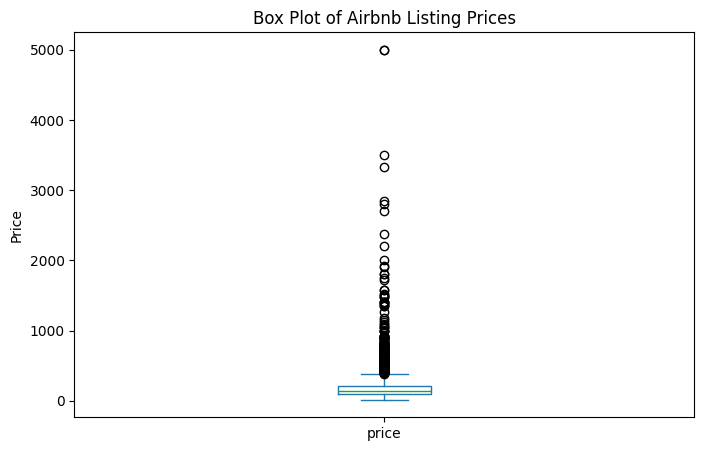

In [100]:
# Create a box plot for the price variable
df['price'].plot(kind='box', figsize=(8, 5))
plt.title("Box Plot of Airbnb Listing Prices")
plt.ylabel("Price")
plt.show()

The box plot shows that the `price` variable is highly right-skewed and contains many extreme values. Most listings are concentrated in a much lower price range, while a small number of observations extend far above the main distribution. These extreme values can have a strong influence on regression models, so it is reasonable to apply a price filter before moving forward.

### 2.6 Filter Extreme Price Values
Based on the price distribution and box plot, the dataset contains some unusually low and very high listing prices. To reduce the influence of extreme outliers, we keep only listings with prices between **10** and **1500**. This range captures the large majority of typical listings while removing observations that could distort the regression models.

In [101]:
# Keep only listings with prices between 10 and 1500
df = df[(df['price'] >= 10) & (df['price'] <= 1500)]
print("Extreme price values filtered successfully.")

# Check the updated dataset shape
print("\nUpdated dataset shape after price filtering:")
print(df.shape)

# Show summary statistics for the filtered price column
print("\nSummary statistics for the filtered price column:")
display(df['price'].describe())

Extreme price values filtered successfully.

Updated dataset shape after price filtering:
(4601, 47)

Summary statistics for the filtered price column:


count    4601.000000
mean      182.223647
std       149.256284
min        14.000000
25%        97.000000
50%       143.000000
75%       211.000000
max      1492.000000
Name: price, dtype: float64

After filtering extreme values, the dataset retains **4,601 listings**. The maximum price is now **1492**, which is much more reasonable for modeling than the earlier extreme values. The price distribution remains right-skewed, but it is now less affected by very large outliers, making it more suitable for regression analysis.

### 2.7 Create a Log-Transformed Target Variable
Even after filtering extreme prices, the target variable remains right-skewed. A log transformation helps reduce skewness, stabilize the spread of values, and make the regression models better suited to the price distribution.

In [102]:
# Create a clean copy of the filtered dataset
df = df.copy()
print("DataFrame copied successfully to avoid chained assignment warnings.")

# Create a log-transformed version of the price column
df['log_price'] = np.log(df['price'])
print("Log-transformed target variable created successfully.")

# Display the first few values of price and log_price
print("\nFirst 5 values of price and log_price:")
display(df[['price', 'log_price']].head())

# Show summary statistics for the log-transformed target
print("\nSummary statistics for the log-transformed target variable:")
display(df['log_price'].describe())

DataFrame copied successfully to avoid chained assignment warnings.
Log-transformed target variable created successfully.

First 5 values of price and log_price:


,price,log_price
0,136.0,4.912655
1,188.0,5.236442
3,47.0,3.850148
4,123.0,4.812184
5,75.0,4.317488



Summary statistics for the log-transformed target variable:


count    4601.000000
mean        4.988816
std         0.629548
min         2.639057
25%         4.574711
50%         4.962845
75%         5.351858
max         7.307873
Name: log_price, dtype: float64

The `log_price` variable was created by applying a natural logarithm to the cleaned price values. This transformation reduces the effect of right skewness and compresses the influence of large prices, which can improve regression model performance. The transformed variable will be used as the target in the modeling stage.

Histogram of the original price variable:


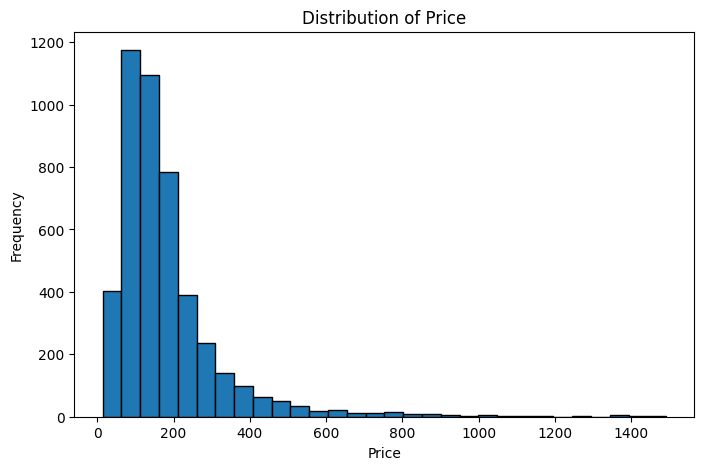

Histogram of the log-transformed price variable:


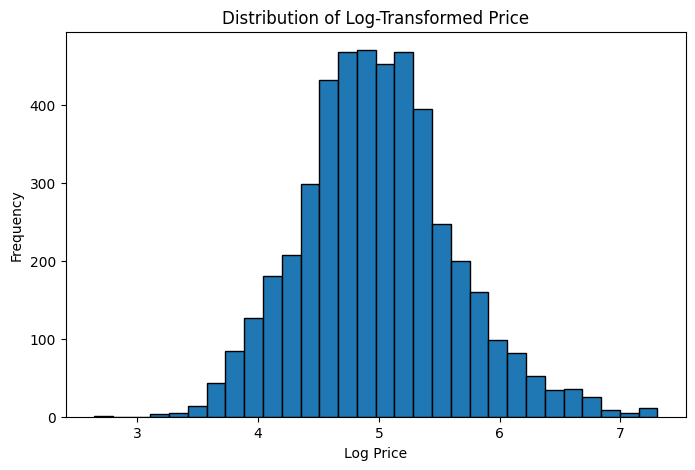

In [103]:
# Plot histogram for the original price variable
print("Histogram of the original price variable:")
plt.figure(figsize=(8, 5))
plt.hist(df['price'], bins=30, edgecolor='k')
plt.title("Distribution of Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

# Plot histogram for the log-transformed price variable
print("Histogram of the log-transformed price variable:")
plt.figure(figsize=(8, 5))
plt.hist(df['log_price'], bins=30, edgecolor='k')
plt.title("Distribution of Log-Transformed Price")
plt.xlabel("Log Price")
plt.ylabel("Frequency")
plt.show()

The histogram of the original `price` variable still shows a clear right-skewed distribution, even after removing extreme outliers. In contrast, the histogram of `log_price` is much more symmetric and closer to a normal distribution. This makes the log-transformed target more suitable for regression modeling, so `log_price` will be used as the main target variable in the next stages of the project.

### 2.8 Review Remaining Columns
After cleaning the target variable and handling extreme price values, it is useful to review the remaining columns in the dataset. This helps identify which variables should be kept for modeling, which should be transformed, and which may still need to be removed.

In [104]:
df.columns

Index(['host_since', 'host_is_superhost', 'host_listings_count',
       'host_total_listings_count', 'neighbourhood_cleansed', 'latitude',
       'longitude', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text',
       'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights',
       'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights',
       'minimum_maximum_nights', 'maximum_maximum_nights',
       'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'has_availability',
       'availability_30', 'availability_60', 'availability_90',
       'availability_365', 'number_of_reviews', 'number_of_reviews_ltm',
       'number_of_reviews_l30d', 'availability_eoy', 'number_of_reviews_ly',
       'estimated_occupancy_l365d', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value', 'instant_bookable',
       'calculated_host_

### 2.9 Remove Redundant and Overly Detailed Columns
At this stage, the dataset is cleaner, but some remaining variables are still redundant, overly detailed, or less useful for a focused regression analysis. These columns are removed to simplify the dataset and keep only the most meaningful features for price prediction.

The following host-related count variables are removed because they are either redundant or too detailed for this project. Keeping too many closely related host-count features can add unnecessary complexity without improving interpretability.

In [105]:
# Drop redundant host count columns
df.drop([
    'host_total_listings_count',
    'calculated_host_listings_count',
    'calculated_host_listings_count_entire_homes',
    'calculated_host_listings_count_private_rooms',
    'calculated_host_listings_count_shared_rooms'
], axis=1, inplace=True)

print("Redundant host count columns removed.")
print("\nUpdated dataset shape:")
print(df.shape)

Redundant host count columns removed.

Updated dataset shape:
(4601, 43)


Several night-related columns are also removed because they provide highly detailed booking rules that are not central to this analysis. The `minimum_nights` variable is retained as the main booking restriction feature.

In [106]:
# Drop overly detailed night-related columns
df.drop([
    'maximum_nights',
    'minimum_minimum_nights',
    'maximum_minimum_nights',
    'minimum_maximum_nights',
    'maximum_maximum_nights',
    'minimum_nights_avg_ntm',
    'maximum_nights_avg_ntm'
], axis=1, inplace=True)

print("Overly detailed night-related columns removed.")
print("\nUpdated dataset shape:")
print(df.shape)

Overly detailed night-related columns removed.

Updated dataset shape:
(4601, 36)


Availability is represented by several overlapping columns measured over different time windows. To avoid redundancy, only `availability_365` is kept because it provides the broadest annual view of listing availability.

In [107]:
# Drop overlapping availability columns
df.drop([
    'has_availability',
    'availability_30',
    'availability_60',
    'availability_90',
    'availability_eoy'
], axis=1, inplace=True)

print("Overlapping availability columns removed.")
print("\nUpdated dataset shape:")
print(df.shape)

Overlapping availability columns removed.

Updated dataset shape:
(4601, 31)


Some review-related columns are removed because they represent narrower time-based versions of the same idea. For a simpler and more interpretable model, the analysis keeps `number_of_reviews` and `reviews_per_month` as the main review activity variables.

In [108]:
# Drop overlapping review activity columns
df.drop([
    'number_of_reviews_ltm',
    'number_of_reviews_l30d',
    'number_of_reviews_ly'
], axis=1, inplace=True)

print("Overlapping review activity columns removed.")
print("\nUpdated dataset shape:")
print(df.shape)

Overlapping review activity columns removed.

Updated dataset shape:
(4601, 28)


The dataset also includes several separate review score dimensions such as accuracy, cleanliness, check-in, and communication. These are useful in some contexts, but for this project they are reduced to the overall rating variable to keep the model simpler and easier to explain.

In [109]:
# Drop detailed review score columns
df.drop([
    'review_scores_accuracy',
    'review_scores_cleanliness',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_location',
    'review_scores_value'
], axis=1, inplace=True)

print("Detailed review score columns removed.")
print("\nUpdated dataset shape:")
print(df.shape)

Detailed review score columns removed.

Updated dataset shape:
(4601, 22)


Finally, a few additional variables are removed because they are either less central to the pricing goal or duplicated in a less useful format. Both `bathrooms` and `bathrooms_text` describe the same feature, but `bathrooms` is retained because it is already in numeric form and has very few missing values. This makes it more practical for regression modeling and avoids the need to parse text values.

In [110]:
# Drop less central or duplicated columns
df.drop([
    'bathrooms_text',
    'estimated_occupancy_l365d'
], axis=1, inplace=True)

print("Additional less central columns removed.")
print("\nFinal dataset shape after column reduction:")
print(df.shape)

Additional less central columns removed.

Final dataset shape after column reduction:
(4601, 20)


After removing redundant, overly detailed, and less useful variables, the dataset now contains **4,601 rows** and **20 columns**. This creates a more focused and manageable dataset for the next stages of the project. The remaining variables preserve the main information needed for price prediction while reducing unnecessary complexity.

### 2.10 Handle Remaining Missing Values
Although the dataset has been reduced to the main modeling variables, a few columns still contain missing values. These need to be addressed before feature engineering and model building so that the dataset is complete and consistent.

The remaining missing values appear in a small number of structured variables. Since these columns are still useful for the analysis, the missing values will be handled rather than removing the columns entirely. A simple and practical strategy is used so the dataset remains suitable for teaching and regression modeling.

In [111]:
# Check missing values in the remaining columns
print("Missing values before treatment:")
print(df.isnull().sum())

Missing values before treatment:
host_since                  0
host_is_superhost         153
host_listings_count         0
neighbourhood_cleansed      0
latitude                    0
longitude                   0
room_type                   0
accommodates                0
bathrooms                   3
bedrooms                    6
beds                        2
amenities                   0
price                       0
minimum_nights              0
availability_365            0
number_of_reviews           0
review_scores_rating      649
instant_bookable            0
reviews_per_month         649
log_price                   0
dtype: int64


In [112]:
# Create a clean copy of the DataFrame to avoid chained assignment warnings
df = df.copy()
print("DataFrame copied successfully.")

# Fill missing values in the host_is_superhost column with 'f'
df['host_is_superhost'] = df['host_is_superhost'].fillna('f')
print("Missing values in host_is_superhost filled with 'f'.")

# Fill missing numeric values with the median of each column
df['bathrooms'] = df['bathrooms'].fillna(df['bathrooms'].median())
df['bedrooms'] = df['bedrooms'].fillna(df['bedrooms'].median())
df['beds'] = df['beds'].fillna(df['beds'].median())
df['review_scores_rating'] = df['review_scores_rating'].fillna(df['review_scores_rating'].median())
df['reviews_per_month'] = df['reviews_per_month'].fillna(df['reviews_per_month'].median())
print("Missing numeric values filled with column medians.")

# Confirm that missing values have been handled
print("\nMissing values after treatment:")
print(df.isnull().sum())

DataFrame copied successfully.
Missing values in host_is_superhost filled with 'f'.
Missing numeric values filled with column medians.

Missing values after treatment:
host_since                0
host_is_superhost         0
host_listings_count       0
neighbourhood_cleansed    0
latitude                  0
longitude                 0
room_type                 0
accommodates              0
bathrooms                 0
bedrooms                  0
beds                      0
amenities                 0
price                     0
minimum_nights            0
availability_365          0
number_of_reviews         0
review_scores_rating      0
instant_bookable          0
reviews_per_month         0
log_price                 0
dtype: int64


The remaining missing values were handled using simple imputation. The binary `host_is_superhost` field was filled with `f`, while missing values in numeric columns were replaced with their median values. Median imputation is a practical choice because it is less sensitive to outliers than the mean and helps keep the dataset complete for modeling.

## 3. Feature Engineering

In this section, additional features are created from the cleaned variables to make the dataset more informative for modeling. Feature engineering helps transform raw variables into more useful predictors that can improve both model performance and interpretation.

### 3.1 Create Amenity Count
The `amenities` column contains a list of features offered by each Airbnb listing. Instead of using the raw text directly, a new variable called `amenity_count` is created to represent how many amenities are included in each listing.

This is a simple summary feature. It does not distinguish between different types of amenities, but it provides a useful overall measure of how many features a listing offers.

In [113]:
# Count the number of amenities listed for each Airbnb property
df['amenity_count'] = df['amenities'].apply(lambda x: len(str(x).split(',')))
print("Amenity count feature created successfully.")

# Display the first few values of amenities and amenity_count
print("\nFirst 5 values of amenities and amenity_count:")
display(df[['amenities', 'amenity_count']].head())

# Show summary statistics for the new feature
print("\nSummary statistics for amenity_count:")
display(df['amenity_count'].describe())

Amenity count feature created successfully.

First 5 values of amenities and amenity_count:


,amenities,amenity_count
0,"[""Hot water"", ""Bed linens"", ""Outdoor furniture...",59
1,"[""Elevator"", ""Baking sheet"", ""Hot water"", ""Dis...",42
3,"[""Hot water"", ""Park view"", ""Outdoor furniture""...",23
4,"[""Hot water"", ""Dishwasher"", ""Bed linens"", ""Out...",48
5,"[""Hair dryer"", ""Refrigerator"", ""Washer"", ""Hot ...",17



Summary statistics for amenity_count:


count    4601.000000
mean       41.780700
std        16.701456
min         1.000000
25%        31.000000
50%        43.000000
75%        52.000000
max       122.000000
Name: amenity_count, dtype: float64

The `amenity_count` feature was successfully created from the `amenities` column. The summary shows that listings vary substantially in the number of amenities they offer, with an average of about **42 amenities** and a median of **43**. This new feature may help capture differences in listing quality and convenience in a more compact numeric form.

### 3.2 Create Host Experience
The `host_since` column shows when each host joined the Airbnb platform. To make this variable more useful for modeling, it is converted into a numeric feature called `host_experience_days`, which measures how long the host has been active on the platform relative to the dataset date.

In [114]:
# Convert host_since from text to datetime format
df['host_since'] = pd.to_datetime(df['host_since'])
print("host_since converted to datetime format successfully.")

# Define the dataset reference date
reference_date = pd.Timestamp('2025-11-17')
print("Reference date set to 2025-11-17.")

# Create a new feature for host experience in days
df['host_experience_days'] = (reference_date - df['host_since']).dt.days
print("host_experience_days feature created successfully.")

# Display the first few values of host_since and host_experience_days
print("\nFirst 5 values of host_since and host_experience_days:")
display(df[['host_since', 'host_experience_days']].head())

# Show summary statistics for host_experience_days
print("\nSummary statistics for host_experience_days:")
display(df['host_experience_days'].describe())

host_since converted to datetime format successfully.
Reference date set to 2025-11-17.
host_experience_days feature created successfully.

First 5 values of host_since and host_experience_days:


,host_since,host_experience_days
0,2009-11-04,5857
1,2009-11-07,5854
3,2010-01-14,5786
4,2010-01-18,5782
5,2010-01-13,5787



Summary statistics for host_experience_days:


count    4601.000000
mean     2548.642034
std      1511.700910
min         4.000000
25%      1185.000000
50%      2548.000000
75%      3732.000000
max      6160.000000
Name: host_experience_days, dtype: float64

The `host_experience_days` feature was successfully created using the dataset date as the reference point. This new variable captures how long each host had been active on the platform at the time of the data snapshot. The summary statistics show substantial variation in host experience, which may help explain differences in pricing behavior across listings.